# SeaDronesSee 30 m → 80 m image-simulation pilot

This notebook creates a **physically constrained approximation**, not a claim that a single 30 m photograph can reproduce a real 80 m observation perfectly. It begins with two training-split images so that the final held-out test videos remain untouched.

For the same camera, focal length, image size, near-nadir view and approximately planar sea surface, ground-sample distance is proportional to height:

$$
\frac{\mathrm{GSD}_{80}}{\mathrm{GSD}_{30}}=\frac{80}{30}=2.667,
\qquad
s=\frac{30}{80}=0.375.
$$

An object should therefore occupy approximately 37.5% as many pixels in each linear dimension at 80 m. To form a 640×640 synthetic 80 m view, the notebook takes approximately a 1707×1707 region from the original 30 m frame and anti-alias downsamples it to 640×640. This preserves real surrounding context when enough source pixels exist.

The pilot separates:

1. **Geometry-only baseline:** larger source footprint plus Lanczos reduction.
2. **Illustrative image-formation effects:** optional extra point-spread blur, incremental atmospheric scattering, shot/read noise and JPEG compression.

The optional effect values are deliberately exposed as parameters. They must later be estimated from genuine high-altitude validation imagery rather than chosen to make results look convincing.

Useful references: [Pix4D ground-sample distance](https://support.pix4d.com/hc/en-us/articles/202559809), [Pillow Lanczos resampling](https://pillow.readthedocs.io/en/latest/handbook/concepts.html), and the [EMVA 1288 sensor-characterisation standard](https://www.emva.org/standards-technology/emva-1288/).

## 1. Configuration

The output remains 640×640 so it can be passed through the same DINOv2 preprocessing and frozen 30 m probe later.

In [3]:
from pathlib import Path
from io import BytesIO
import json
import math

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image, ImageDraw, ImageFilter


def find_repo_root(start=None):
    current = Path(start or Path.cwd()).resolve()
    for candidate in [current, *current.parents]:
        if (candidate / ".git").exists():
            return candidate
    raise FileNotFoundError("Run this notebook from inside the repository.")


REPO_ROOT = find_repo_root()
SPLIT_PATH = REPO_ROOT / "data" / "splits" / "seadronessee" / "seadronessee_25_35m_object_split.csv"
RESULT_DIR = REPO_ROOT / "results" / "seadronessee_30m_to_80m_pilot"
RESULT_DIR.mkdir(parents=True, exist_ok=True)

FROM_ALTITUDE_M = 30.0
TO_ALTITUDE_M = 80.0
OUTPUT_SIDE_PX = 640
ALTITUDE_SCALE = FROM_ALTITUDE_M / TO_ALTITUDE_M
FOOTPRINT_FACTOR = TO_ALTITUDE_M / FROM_ALTITUDE_M
SOURCE_SIDE_PX = int(round(OUTPUT_SIDE_PX * FOOTPRINT_FACTOR))
RANDOM_SEED = 42

print(f"Linear object scale: {ALTITUDE_SCALE:.3f}")
print(f"Ground-footprint factor: {FOOTPRINT_FACTOR:.3f}")
print(f"Source crop: {SOURCE_SIDE_PX}×{SOURCE_SIDE_PX} → output: {OUTPUT_SIDE_PX}×{OUTPUT_SIDE_PX}")

Linear object scale: 0.375
Ground-footprint factor: 2.667
Source crop: 1707×1707 → output: 640×640


## 2. Select two development images

The examples come from the **training split**, not the final test videos. They are chosen only when the required 1707-pixel source crop fits completely inside the original frame. One boat and one swimmer are selected near the median bounding-box area of the eligible examples.

In [4]:
objects = pd.read_csv(SPLIT_PATH)
objects["image_path"] = objects["image_path"].map(lambda value: str((REPO_ROOT / Path(value)).resolve()))

objects["center_x"] = objects["bbox_x"] + objects["bbox_width"] / 2.0
objects["center_y"] = objects["bbox_y"] + objects["bbox_height"] / 2.0
objects["required_source_side_px"] = np.rint(
    OUTPUT_SIDE_PX * TO_ALTITUDE_M / objects["altitude_m"]
).astype(int)
margin = objects["required_source_side_px"] / 2.0
objects["large_crop_fits"] = (
    (objects["center_x"] >= margin)
    & (objects["center_y"] >= margin)
    & (objects["center_x"] <= objects["image_width"] - margin)
    & (objects["center_y"] <= objects["image_height"] - margin)
)

eligible = objects[(objects["split"] == "train") & objects["large_crop_fits"]].copy()
chosen = []
used_image_keys = set()
for class_name in ["boat", "swimmer"]:
    candidates = eligible[(eligible["category_name"] == class_name) & (~eligible["image_key"].isin(used_image_keys))].copy()
    near_nominal = candidates[(candidates["altitude_m"] - FROM_ALTITUDE_M).abs() <= 0.5]
    if not near_nominal.empty:
        candidates = near_nominal
    if candidates.empty:
        raise RuntimeError(f"No eligible {class_name!r} example has enough surrounding context.")
    median_area = candidates["bbox_area"].median()
    selected_index = (candidates["bbox_area"] - median_area).abs().idxmin()
    selected_row = eligible.loc[selected_index]
    chosen.append(selected_row)
    used_image_keys.add(selected_row["image_key"])

samples = pd.DataFrame(chosen).reset_index(drop=True)
display(samples[["category_name", "file_name", "altitude_m", "required_source_side_px", "bbox_width", "bbox_height", "video"]])

,category_name,file_name,altitude_m,required_source_side_px,bbox_width,bbox_height,video
0,boat,16280.jpg,29.898542,1712,203.0,56.0,DJI_0010_d3.mov
1,swimmer,10394.jpg,30.198527,1695,30.0,30.0,NorthSea_Sat_DJI_0126.MP4


## 3. Image-formation functions

The operation order is:

```text
larger 30 m source region
        ↓ optional additional optical PSF
anti-aliased scale reduction
        ↓ incremental atmospheric scattering
        ↓ shot/read noise
        ↓ JPEG compression
synthetic 80 m image
```

Atmospheric transmission is represented as

$$
I = Jt + A(1-t), \qquad t=\exp(-\beta d).
$$

Only the additional 50 m path is applied because the source image already contains its original 30 m atmospheric path. With 15 km meteorological visibility, the additional transmission is approximately 0.987, so the haze contribution is small. Blur, noise and compression are also not automatic consequences of altitude; they are optional factors for later calibration.

In [5]:
def srgb_to_linear(values):
    values = np.asarray(values, dtype=np.float32)
    return np.where(values <= 0.04045, values / 12.92, ((values + 0.055) / 1.055) ** 2.4)


def linear_to_srgb(values):
    values = np.clip(values, 0.0, 1.0)
    return np.where(values <= 0.0031308, values * 12.92, 1.055 * values ** (1.0 / 2.4) - 0.055)


def centred_crop_with_bbox(image, row, side):
    center_x = float(row["bbox_x"] + row["bbox_width"] / 2.0)
    center_y = float(row["bbox_y"] + row["bbox_height"] / 2.0)
    left = int(round(center_x - side / 2.0))
    top = int(round(center_y - side / 2.0))
    right = left + side
    bottom = top + side
    if left < 0 or top < 0 or right > image.width or bottom > image.height:
        raise ValueError("Requested source footprint extends beyond this image.")

    crop = image.crop((left, top, right, bottom))
    bbox_in_crop = (
        float(row["bbox_x"] - left),
        float(row["bbox_y"] - top),
        float(row["bbox_width"]),
        float(row["bbox_height"]),
    )
    return crop, bbox_in_crop


def apply_incremental_haze(image, extra_distance_m, visibility_m, airlight_srgb):
    # Koschmieder visibility relation at a 2% contrast threshold: beta = 3.912 / V.
    beta = 3.912 / float(visibility_m)
    transmission = math.exp(-beta * float(extra_distance_m))
    srgb = np.asarray(image, dtype=np.float32) / 255.0
    linear = srgb_to_linear(srgb)
    airlight_linear = srgb_to_linear(np.asarray(airlight_srgb, dtype=np.float32))
    hazy_linear = linear * transmission + airlight_linear[None, None, :] * (1.0 - transmission)
    output = np.round(linear_to_srgb(hazy_linear) * 255.0).astype(np.uint8)
    return Image.fromarray(output, mode="RGB"), transmission


def apply_sensor_noise(image, peak_electrons, read_noise_electrons, rng):
    srgb = np.asarray(image, dtype=np.float32) / 255.0
    linear = srgb_to_linear(srgb)
    expected_electrons = np.clip(linear * float(peak_electrons), 0.0, None)
    shot = rng.poisson(expected_electrons).astype(np.float32)
    read = rng.normal(0.0, float(read_noise_electrons), size=shot.shape).astype(np.float32)
    noisy_linear = np.clip((shot + read) / float(peak_electrons), 0.0, 1.0)
    output = np.round(linear_to_srgb(noisy_linear) * 255.0).astype(np.uint8)
    return Image.fromarray(output, mode="RGB")


def jpeg_round_trip(image, quality):
    buffer = BytesIO()
    image.save(buffer, format="JPEG", quality=int(quality), subsampling=2)
    buffer.seek(0)
    with Image.open(buffer) as encoded:
        return encoded.convert("RGB")


def simulate_30m_to_80m(image, row, effects=None, seed=42):
    effects = effects or {}
    source_altitude_m = float(row["altitude_m"])
    source_side_px = int(round(OUTPUT_SIDE_PX * TO_ALTITUDE_M / source_altitude_m))
    source_crop, source_bbox = centred_crop_with_bbox(image, row, source_side_px)

    # Optional *additional* PSF, expressed in final output pixels.
    sigma_output = float(effects.get("extra_psf_sigma_output_px", 0.0))
    altitude_scale = source_altitude_m / TO_ALTITUDE_M
    if sigma_output > 0:
        sigma_source = sigma_output / altitude_scale
        source_crop = source_crop.filter(ImageFilter.GaussianBlur(radius=sigma_source))

    output = source_crop.resize(
        (OUTPUT_SIDE_PX, OUTPUT_SIDE_PX),
        resample=Image.Resampling.LANCZOS,
    )
    actual_scale = OUTPUT_SIDE_PX / source_side_px
    output_bbox = tuple(value * actual_scale for value in source_bbox)

    transmission = 1.0
    visibility_m = effects.get("visibility_m")
    if visibility_m is not None:
        output, transmission = apply_incremental_haze(
            output,
            extra_distance_m=TO_ALTITUDE_M - FROM_ALTITUDE_M,
            visibility_m=float(visibility_m),
            airlight_srgb=effects.get("airlight_srgb", (0.78, 0.84, 0.90)),
        )

    peak_electrons = effects.get("peak_electrons")
    if peak_electrons is not None:
        output = apply_sensor_noise(
            output,
            peak_electrons=float(peak_electrons),
            read_noise_electrons=float(effects.get("read_noise_electrons", 2.0)),
            rng=np.random.default_rng(seed),
        )

    jpeg_quality = effects.get("jpeg_quality")
    if jpeg_quality is not None:
        output = jpeg_round_trip(output, quality=int(jpeg_quality))

    metadata = {
        "actual_scale": actual_scale,
        "source_side_px": source_side_px,
        "output_side_px": OUTPUT_SIDE_PX,
        "transmission": transmission,
        "output_bbox": output_bbox,
    }
    return output, metadata


def draw_bbox(image, bbox, colour=(40, 255, 40)):
    rendered = image.copy()
    draw = ImageDraw.Draw(rendered)
    x, y, width, height = bbox
    line_width = max(2, int(round(rendered.width / 220)))
    draw.rectangle((x, y, x + width, y + height), outline=colour, width=line_width)
    return rendered

## 4. Choose an illustrative effect setting

These values are starting points for visual inspection only. The geometry-only result is the scientifically defensible baseline. Do not call the second version “realistic” until its blur, noise, colour and compression statistics have been calibrated against separate genuine 80 m images.

In [6]:
ILLUSTRATIVE_EFFECTS = {
    # Small extra PSF in final output pixels. Set to 0 to disable.
    "extra_psf_sigma_output_px": 0.35,
    # Incremental haze over 50 m. Larger visibility means less haze.
    "visibility_m": 15_000.0,
    "airlight_srgb": (0.78, 0.84, 0.90),
    # Simple linear-light shot/read-noise approximation.
    "peak_electrons": 8_000.0,
    "read_noise_electrons": 2.0,
    # Final camera/video compression approximation.
    "jpeg_quality": 95,
}

extra_distance = TO_ALTITUDE_M - FROM_ALTITUDE_M
beta = 3.912 / ILLUSTRATIVE_EFFECTS["visibility_m"]
print(f"Extra-path atmospheric transmission: {math.exp(-beta * extra_distance):.4f}")
print("Parameters:", json.dumps(ILLUSTRATIVE_EFFECTS, indent=2))

Extra-path atmospheric transmission: 0.9870
Parameters: {
  "extra_psf_sigma_output_px": 0.35,
  "visibility_m": 15000.0,
  "airlight_srgb": [
    0.78,
    0.84,
    0.9
  ],
  "peak_electrons": 8000.0,
  "read_noise_electrons": 2.0,
  "jpeg_quality": 95
}


## 5. Generate and inspect the two-image pilot

The green rectangle comes from the original SeaDronesSee annotation and is transformed using the same geometric scale as the image. The first column is the existing 640-pixel 30 m classifier input. The next two columns show the geometry-only and optional-effects simulations.

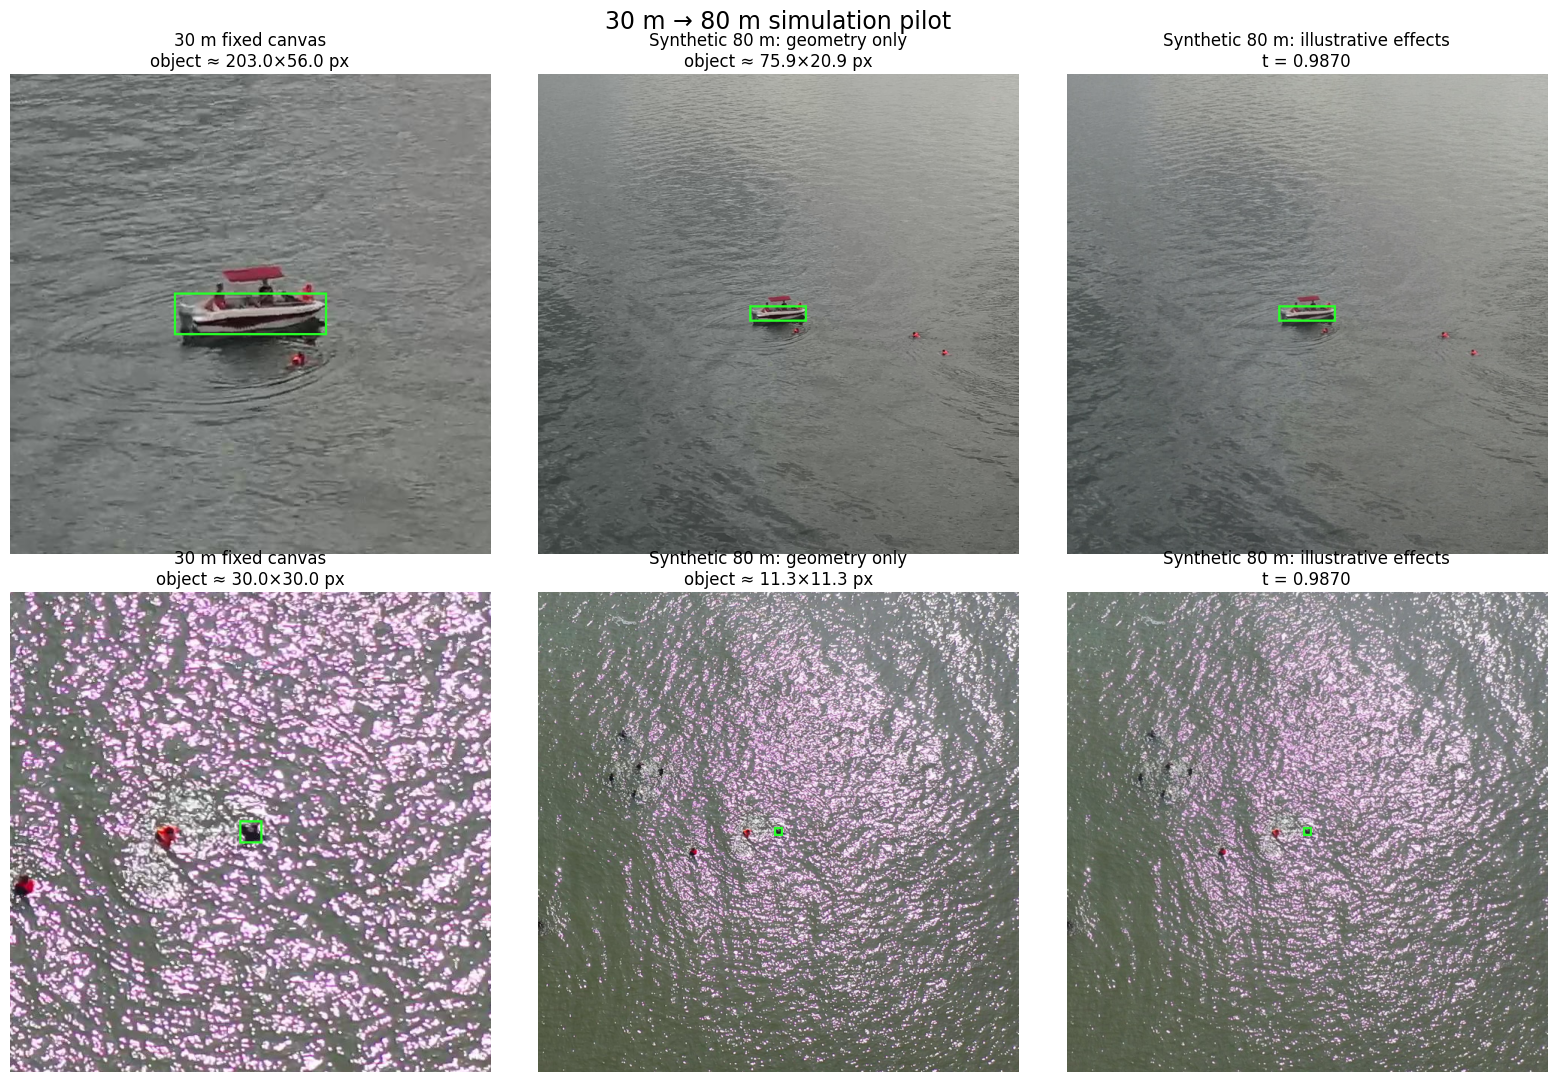

Saved figure: C:\Users\ADMIN\Desktop\fastr\uav-altitude-feature-alignment\results\seadronessee_30m_to_80m_pilot\pilot_comparison.png
Saved manifest: C:\Users\ADMIN\Desktop\fastr\uav-altitude-feature-alignment\results\seadronessee_30m_to_80m_pilot\pilot_manifest.csv


,class_name,source_file,source_altitude_m,source_bbox_width_px,source_bbox_height_px,synthetic_bbox_width_px,synthetic_bbox_height_px,linear_scale,source_crop_side_px,output_side_px,transmission
0,boat,16280.jpg,29.898542,203.0,56.0,75.887850,20.934579,0.373832,1712,640,0.987045
1,swimmer,10394.jpg,30.198527,30.0,30.0,11.327434,11.327434,0.377581,1695,640,0.987045


In [7]:
records = []
fig, axes = plt.subplots(len(samples), 3, figsize=(16, 5.5 * len(samples)))
axes = np.atleast_2d(axes)

for sample_index, row in samples.iterrows():
    with Image.open(row["image_path"]) as source_file:
        source = source_file.convert("RGB")

    input_30m, bbox_30m = centred_crop_with_bbox(source, row, OUTPUT_SIDE_PX)
    synthetic_geometry, geometry_meta = simulate_30m_to_80m(source, row, effects=None, seed=RANDOM_SEED + sample_index)
    synthetic_effects, effects_meta = simulate_30m_to_80m(
        source,
        row,
        effects=ILLUSTRATIVE_EFFECTS,
        seed=RANDOM_SEED + sample_index,
    )

    bbox_80m = geometry_meta["output_bbox"]
    images = [
        draw_bbox(input_30m, bbox_30m),
        draw_bbox(synthetic_geometry, bbox_80m),
        draw_bbox(synthetic_effects, bbox_80m),
    ]
    original_size = (float(row["bbox_width"]), float(row["bbox_height"]))
    simulated_size = (bbox_80m[2], bbox_80m[3])
    titles = [
        f"30 m fixed canvas\nobject ≈ {original_size[0]:.1f}×{original_size[1]:.1f} px",
        f"Synthetic 80 m: geometry only\nobject ≈ {simulated_size[0]:.1f}×{simulated_size[1]:.1f} px",
        f"Synthetic 80 m: illustrative effects\nt = {effects_meta['transmission']:.4f}",
    ]

    for axis, rendered, title in zip(axes[sample_index], images, titles):
        axis.imshow(rendered)
        axis.set_title(title)
        axis.axis("off")
    axes[sample_index, 0].set_ylabel(
        f"{row['category_name']}\n{row['altitude_m']:.1f} m source",
        fontsize=12,
    )

    stem = f"{sample_index + 1}_{row['category_name']}_{Path(row['file_name']).stem}"
    input_30m.save(RESULT_DIR / f"{stem}_30m.png")
    synthetic_geometry.save(RESULT_DIR / f"{stem}_synthetic80_geometry.png")
    synthetic_effects.save(RESULT_DIR / f"{stem}_synthetic80_effects.png")
    records.append({
        "class_name": row["category_name"],
        "source_file": row["file_name"],
        "source_altitude_m": float(row["altitude_m"]),
        "source_bbox_width_px": original_size[0],
        "source_bbox_height_px": original_size[1],
        "synthetic_bbox_width_px": simulated_size[0],
        "synthetic_bbox_height_px": simulated_size[1],
        "linear_scale": geometry_meta["actual_scale"],
        "source_crop_side_px": geometry_meta["source_side_px"],
        "output_side_px": OUTPUT_SIDE_PX,
        "transmission": effects_meta["transmission"],
    })

fig.suptitle("30 m → 80 m simulation pilot", fontsize=17)
plt.tight_layout()
figure_path = RESULT_DIR / "pilot_comparison.png"
fig.savefig(figure_path, dpi=180, bbox_inches="tight")
plt.show()

manifest = pd.DataFrame(records)
manifest_path = RESULT_DIR / "pilot_manifest.csv"
manifest.to_csv(manifest_path, index=False)
print("Saved figure:", figure_path)
print("Saved manifest:", manifest_path)
display(manifest)

## 6. What this pilot can and cannot establish

### Captured by the pilot

- The first-order GSD/scale change under the same camera geometry.
- The wider local ground footprint, because a larger region of the original frame is used.
- Anti-aliased spatial reduction.
- Parameterised approximations of extra PSF blur, homogeneous haze, sensor noise and JPEG compression.
- Exact transformation of the object annotation into the synthetic view.

### Not recoverable from one 30 m image

- Ground or water outside the original frame.
- True 3D parallax, occlusion changes and different visible object surfaces.
- Changed waves, reflections, object motion or drone position at another capture time.
- Camera autofocus, exposure, stabilisation, rolling shutter and video-encoder behaviour that was not measured.
- Spatially varying atmospheric scattering without a scene-depth map.

For SeaDronesSee over water, geometry is expected to be the main controlled effect. Additional haze or blur should be retained only if real 70–100 m validation images show the same statistical change after controlling for camera, class, gimbal pitch, lighting and source video.

### Next experiment

1. Compare synthetic object-size distributions with genuine 70–100 m annotations.
2. Estimate blur, noise, colour and compression parameters using a **validation** subset of real high-altitude videos.
3. Freeze those parameters.
4. Extract DINOv2 features from real 30 m, synthetic 80 m and untouched real high-altitude test images.
5. Fit Procrustes only on the intended calibration data and report performance on independent real high-altitude videos.

## 7. Calibrate optional effects with separate real 80 m videos

This extension uses real SeaDronesSee images near 80 m to calibrate **low-level appearance statistics**, without using object-category labels or recognition accuracy. It therefore remains a calibration-assisted simulator rather than supervised object-model fine-tuning.

Complete source videos are assigned to one role:

```text
Calibration: NorthSea_Thu_DJI_0107.MP4 and NorthSea_Sat_DJI_0129.MP4
Validation:  NorthSea_Sat_DJI_0131.MP4
Final test:  DJI_0064.MP4 and DJI_0065.MP4 (reserved; pixels are not opened here)
```

The calibration and validation comparisons use 75–85 m images. Low-altitude source images come from the same calibration or validation videos where available, reducing camera and scene confounding. Every comparison uses unlabelled centre patches; bounding boxes and category names are not used.

In [8]:
import itertools
import seaborn as sns

ODV2_ROOT = REPO_ROOT / "data" / "raw" / "seadronessee" / "odv2"
REAL80_MIN_M = 75.0
REAL80_MAX_M = 85.0
PATCHES_PER_VIDEO = 4

CALIBRATION_VIDEOS = [
    "NorthSea_Thu_DJI_0107.MP4",
    "NorthSea_Sat_DJI_0129.MP4",
]
VALIDATION_VIDEOS = ["NorthSea_Sat_DJI_0131.MP4"]
HELDOUT_TEST_VIDEOS = ["DJI_0064.MP4", "DJI_0065.MP4"]

assert not (set(CALIBRATION_VIDEOS) & set(VALIDATION_VIDEOS))
assert not (set(CALIBRATION_VIDEOS) & set(HELDOUT_TEST_VIDEOS))
assert not (set(VALIDATION_VIDEOS) & set(HELDOUT_TEST_VIDEOS))


def load_altitude_image_table():
    rows = []
    for source_split in ["train", "val"]:
        annotation_path = ODV2_ROOT / "annotations" / f"instances_{source_split}.json"
        with annotation_path.open("r", encoding="utf-8") as handle:
            coco = json.load(handle)
        for image_record in coco["images"]:
            meta = image_record.get("meta") or {}
            source = image_record.get("source") or {}
            altitude = meta.get("height_above_takeoff(meter)")
            if altitude is None:
                continue
            rows.append({
                "image_key": f"{source_split}:{image_record['id']}",
                "source_split": source_split,
                "file_name": image_record["file_name"],
                "image_width": int(image_record["width"]),
                "image_height": int(image_record["height"]),
                "altitude_m": float(altitude),
                "gimbal_pitch_deg": meta.get("gimbal_pitch(degrees)"),
                "drone": source.get("drone", "unknown"),
                "video": source.get("video", f"video_{image_record.get('video_id', 'unknown')}"),
                "frame_no": int(source.get("frame_no", image_record.get("frame_index", image_record["id"]))),
                "image_path": str((ODV2_ROOT / "images" / source_split / image_record["file_name"]).resolve()),
            })
    return pd.DataFrame(rows)


def select_evenly_by_video(frame, videos, per_video=4):
    selected = []
    for video in videos:
        group = frame[frame["video"] == video].sort_values(["frame_no", "image_key"]).reset_index(drop=True)
        if group.empty:
            raise RuntimeError(f"No eligible images were found for {video}.")
        count = min(per_video, len(group))
        indices = np.unique(np.rint(np.linspace(0, len(group) - 1, count)).astype(int))
        selected.append(group.iloc[indices])
    return pd.concat(selected, ignore_index=True)


all_altitude_images = load_altitude_image_table()
real80_images = all_altitude_images[
    all_altitude_images["altitude_m"].between(REAL80_MIN_M, REAL80_MAX_M, inclusive="both")
].copy()

# The existing 30 m manifest has repeated object rows; retain one row per image.
low_image_table = (
    objects.sort_values(["video", "frame_no", "image_key"])
    .drop_duplicates("image_key")
    .copy()
)

real80_calibration = select_evenly_by_video(real80_images, CALIBRATION_VIDEOS, PATCHES_PER_VIDEO)
real80_validation = select_evenly_by_video(real80_images, VALIDATION_VIDEOS, PATCHES_PER_VIDEO * 2)
low_calibration = select_evenly_by_video(low_image_table, CALIBRATION_VIDEOS, PATCHES_PER_VIDEO)
low_validation = select_evenly_by_video(low_image_table, VALIDATION_VIDEOS, PATCHES_PER_VIDEO * 2)

assert set(real80_calibration["video"]).isdisjoint(set(real80_validation["video"]))
assert set(real80_calibration["video"]).isdisjoint(set(HELDOUT_TEST_VIDEOS))
assert set(real80_validation["video"]).isdisjoint(set(HELDOUT_TEST_VIDEOS))

summary_rows = []
for name, frame in [
    ("real80_calibration", real80_calibration),
    ("real80_validation", real80_validation),
    ("low_calibration", low_calibration),
    ("low_validation", low_validation),
]:
    summary_rows.append({
        "group": name,
        "images": len(frame),
        "videos": frame["video"].nunique(),
        "altitude_min": frame["altitude_m"].min(),
        "altitude_median": frame["altitude_m"].median(),
        "altitude_max": frame["altitude_m"].max(),
    })

display(pd.DataFrame(summary_rows))
print("Reserved final-test videos (not opened by calibration):")
for video in HELDOUT_TEST_VIDEOS:
    print(" ", video)

,group,images,videos,altitude_min,altitude_median,altitude_max
0,real80_calibration,8,2,76.496269,79.846106,84.795865
1,real80_validation,8,1,76.196284,79.046145,84.695870
2,low_calibration,8,2,28.598605,32.498415,34.598313
3,low_validation,8,1,25.298766,27.548657,34.598313


Reserved final-test videos (not opened by calibration):
  DJI_0064.MP4
  DJI_0065.MP4


## 8. Create unlabelled centre patches and image statistics

For each low-altitude image, a larger centre region is reduced according to its recorded altitude. Genuine 75–85 m images contribute a native 640×640 centre crop. The comparison uses five interpretable statistics:

- mean linear luminance;
- coefficient of luminance contrast;
- mean colour saturation;
- normalised neighbour-gradient energy;
- an 8-pixel boundary ratio sensitive to block compression.

These statistics cannot perfectly separate blur, water texture, noise and compression. The separate validation video is therefore essential.

In [9]:
CALIBRATION_METRICS = [
    "luminance_mean",
    "contrast",
    "saturation",
    "gradient_ratio",
    "blockiness",
]
METRIC_WEIGHTS = {
    "luminance_mean": 0.25,
    "contrast": 1.0,
    "saturation": 0.5,
    "gradient_ratio": 1.5,
    "blockiness": 0.75,
}


def centre_crop(image, side):
    if side > image.width or side > image.height:
        raise ValueError(f"A {side}px crop does not fit inside {image.size}.")
    left = int(round((image.width - side) / 2.0))
    top = int(round((image.height - side) / 2.0))
    return image.crop((left, top, left + side, top + side))


def prepare_low_sources(frame):
    prepared = []
    for row in frame.itertuples(index=False):
        source_side = int(round(OUTPUT_SIDE_PX * TO_ALTITUDE_M / float(row.altitude_m)))
        with Image.open(row.image_path) as source_file:
            crop = centre_crop(source_file.convert("RGB"), source_side)
        prepared.append({
            "image_key": row.image_key,
            "video": row.video,
            "altitude_m": float(row.altitude_m),
            "source_side_px": source_side,
            "crop": crop,
        })
    return prepared


def prepare_real80_targets(frame):
    prepared = []
    for row in frame.itertuples(index=False):
        with Image.open(row.image_path) as source_file:
            crop = centre_crop(source_file.convert("RGB"), OUTPUT_SIDE_PX)
        prepared.append({
            "image_key": row.image_key,
            "video": row.video,
            "altitude_m": float(row.altitude_m),
            "image": crop,
        })
    return prepared


def render_prepared_source(item, effects=None, seed=42):
    effects = effects or {}
    crop = item["crop"].copy()
    altitude_scale = float(item["altitude_m"]) / TO_ALTITUDE_M

    sigma_output = float(effects.get("extra_psf_sigma_output_px", 0.0) or 0.0)
    if sigma_output > 0:
        crop = crop.filter(ImageFilter.GaussianBlur(radius=sigma_output / altitude_scale))

    output = crop.resize((OUTPUT_SIDE_PX, OUTPUT_SIDE_PX), Image.Resampling.LANCZOS)

    visibility_m = effects.get("visibility_m")
    if visibility_m is not None:
        output, _ = apply_incremental_haze(
            output,
            extra_distance_m=TO_ALTITUDE_M - float(item["altitude_m"]),
            visibility_m=float(visibility_m),
            airlight_srgb=effects.get("airlight_srgb", (0.78, 0.84, 0.90)),
        )

    peak_electrons = effects.get("peak_electrons")
    if peak_electrons is not None:
        output = apply_sensor_noise(
            output,
            peak_electrons=float(peak_electrons),
            read_noise_electrons=float(effects.get("read_noise_electrons", 2.0)),
            rng=np.random.default_rng(seed),
        )

    jpeg_quality = effects.get("jpeg_quality")
    if jpeg_quality is not None:
        output = jpeg_round_trip(output, int(jpeg_quality))
    return output


def image_statistics(image):
    srgb = np.asarray(image, dtype=np.float32) / 255.0
    linear = srgb_to_linear(srgb)
    luminance = 0.2126 * linear[..., 0] + 0.7152 * linear[..., 1] + 0.0722 * linear[..., 2]
    mean_luminance = float(luminance.mean())
    std_luminance = float(luminance.std())

    dx = np.abs(np.diff(luminance, axis=1))
    dy = np.abs(np.diff(luminance, axis=0))
    gradient_rms = float(np.sqrt(np.mean(dx * dx) + np.mean(dy * dy)))

    maximum = srgb.max(axis=2)
    minimum = srgb.min(axis=2)
    saturation = (maximum - minimum) / np.maximum(maximum, 1e-6)

    # diff[:, 7] is the transition between JPEG columns 7 and 8.
    boundary_values = dx[:, 7::8]
    boundary_mask = np.ones(dx.shape[1], dtype=bool)
    boundary_mask[7::8] = False
    non_boundary_values = dx[:, boundary_mask]
    blockiness = float(boundary_values.mean() / max(non_boundary_values.mean(), 1e-8))

    return {
        "luminance_mean": mean_luminance,
        "contrast": std_luminance / max(mean_luminance, 1e-6),
        "saturation": float(saturation.mean()),
        "gradient_ratio": gradient_rms / max(std_luminance, 1e-6),
        "blockiness": blockiness,
    }


def statistics_frame(images, group_name):
    rows = []
    for index, item in enumerate(images):
        image = item["image"] if "image" in item else item
        rows.append({"sample": index, "group": group_name, **image_statistics(image)})
    return pd.DataFrame(rows)


def distribution_score(candidate_stats, target_stats):
    total = 0.0
    details = {}
    for metric in CALIBRATION_METRICS:
        candidate_values = candidate_stats[metric].to_numpy(float)
        target_values = target_stats[metric].to_numpy(float)
        candidate_median = float(np.median(candidate_values))
        target_median = float(np.median(target_values))
        candidate_iqr = float(np.quantile(candidate_values, 0.75) - np.quantile(candidate_values, 0.25))
        target_iqr = float(np.quantile(target_values, 0.75) - np.quantile(target_values, 0.25))
        robust_scale = max(target_iqr, 0.10 * abs(target_median), 1e-4)
        location_error = abs(candidate_median - target_median) / robust_scale
        spread_error = abs(candidate_iqr - target_iqr) / robust_scale
        metric_score = METRIC_WEIGHTS[metric] * (location_error + 0.25 * spread_error)
        details[f"{metric}_score"] = metric_score
        total += metric_score
    return float(total), details


calibration_sources = prepare_low_sources(low_calibration)
validation_sources = prepare_low_sources(low_validation)
calibration_targets = prepare_real80_targets(real80_calibration)
validation_targets = prepare_real80_targets(real80_validation)
real80_calibration_stats = statistics_frame(calibration_targets, "real 80 m calibration")
real80_validation_stats = statistics_frame(validation_targets, "real 80 m validation")
print(f"Prepared {len(calibration_sources)} low-altitude calibration sources")
print(f"Prepared {len(calibration_targets)} genuine 80 m calibration targets")
print(f"Prepared {len(validation_sources)} low-altitude validation sources")
print(f"Prepared {len(validation_targets)} genuine 80 m validation targets")

Prepared 8 low-altitude calibration sources
Prepared 8 genuine 80 m calibration targets
Prepared 8 low-altitude validation sources
Prepared 8 genuine 80 m validation targets


## 9. Small, transparent calibration grid

The search is intentionally small to reduce overfitting. It compares geometry-only output with combinations of mild PSF blur, two haze levels, one sensor-noise setting and one extra JPEG setting. Every candidate is scored against the real-80 m **calibration** distribution. No recognition labels or classifier outputs are used.

In [10]:
def infer_pillow_jpeg_quality(image_path):
    with Image.open(image_path) as source:
        target_tables = source.quantization or {}
    target = np.concatenate([np.asarray(target_tables[key], dtype=float) for key in sorted(target_tables)])
    reference = Image.new("RGB", (16, 16), (128, 128, 128))
    best_quality, best_error = None, math.inf
    for quality in range(1, 101):
        buffer = BytesIO()
        reference.save(buffer, format="JPEG", quality=quality, subsampling=2)
        buffer.seek(0)
        with Image.open(buffer) as candidate:
            candidate_tables = candidate.quantization or {}
        values = np.concatenate([np.asarray(candidate_tables[key], dtype=float) for key in sorted(candidate_tables)])
        error = float(np.abs(values - target).sum())
        if error < best_error:
            best_quality, best_error = quality, error
    return int(best_quality), best_error


low_jpeg_quality, low_qtable_error = infer_pillow_jpeg_quality(low_calibration.iloc[0]["image_path"])
real80_jpeg_quality, real80_qtable_error = infer_pillow_jpeg_quality(real80_calibration.iloc[0]["image_path"])
print(f"Low-altitude JPEG tables correspond to quality {low_jpeg_quality} (error {low_qtable_error:.0f})")
print(f"Real-80 JPEG tables correspond to quality {real80_jpeg_quality} (error {real80_qtable_error:.0f})")

BLUR_GRID = [0.0, 0.35, 0.70]
VISIBILITY_GRID = [None, 15_000.0, 8_000.0]
PEAK_ELECTRONS_GRID = [None, 8_000.0]
JPEG_QUALITY_GRID = list(dict.fromkeys([None, real80_jpeg_quality, 85, 95]))
AIRLIGHT_SRGB = (0.78, 0.84, 0.90)
READ_NOISE_ELECTRONS = 2.0

search_rows = []
for candidate_index, (blur, visibility, peak_electrons, jpeg_quality) in enumerate(
    itertools.product(BLUR_GRID, VISIBILITY_GRID, PEAK_ELECTRONS_GRID, JPEG_QUALITY_GRID)
):
    effects = {
        "extra_psf_sigma_output_px": blur,
        "visibility_m": visibility,
        "airlight_srgb": AIRLIGHT_SRGB,
        "peak_electrons": peak_electrons,
        "read_noise_electrons": READ_NOISE_ELECTRONS,
        "jpeg_quality": jpeg_quality,
    }
    rendered = [
        {"image": render_prepared_source(item, effects, seed=RANDOM_SEED + item_index)}
        for item_index, item in enumerate(calibration_sources)
    ]
    candidate_stats = statistics_frame(rendered, "synthetic candidate")
    score, score_details = distribution_score(candidate_stats, real80_calibration_stats)
    search_rows.append({
        "blur_sigma_output_px": blur,
        "visibility_m": visibility,
        "peak_electrons": peak_electrons,
        "jpeg_quality": jpeg_quality,
        "calibration_score": score,
        **score_details,
    })

calibration_search = pd.DataFrame(search_rows).sort_values("calibration_score").reset_index(drop=True)
search_path = RESULT_DIR / "calibration_search.csv"
calibration_search.to_csv(search_path, index=False)
display(calibration_search.head(10))
print("Saved search:", search_path)

Low-altitude JPEG tables correspond to quality 75 (error 0)
Real-80 JPEG tables correspond to quality 75 (error 0)


,blur_sigma_output_px,visibility_m,peak_electrons,jpeg_quality,calibration_score,luminance_mean_score,contrast_score,saturation_score,gradient_ratio_score,blockiness_score
0,0.00,NaN,NaN,95.0,11.318515,0.049106,4.860750,0.694145,5.233841,0.480673
1,0.00,NaN,8000.0,95.0,11.337642,0.048852,4.885020,0.699970,5.084241,0.619560
2,0.00,15000.0,8000.0,95.0,11.370117,0.072844,4.927831,0.735762,5.080480,0.553201
3,0.00,15000.0,NaN,95.0,11.400189,0.072428,4.966548,0.713759,5.211178,0.436277
4,0.00,8000.0,8000.0,95.0,11.479120,0.093301,5.007685,0.828578,5.042244,0.507313
5,0.00,8000.0,NaN,95.0,11.487279,0.093038,5.042128,0.815921,5.175454,0.360737
6,0.00,NaN,8000.0,NaN,12.466565,0.049260,4.848026,0.231581,5.141229,2.196470
7,0.35,NaN,8000.0,95.0,13.065260,0.048052,5.216403,0.703196,6.737968,0.359643
8,0.00,15000.0,8000.0,NaN,13.075454,0.073104,4.942747,0.725123,5.114702,2.219778
9,0.35,NaN,NaN,95.0,13.106983,0.048307,5.237864,0.695087,6.911983,0.213743


Saved search: C:\Users\ADMIN\Desktop\fastr\uav-altitude-feature-alignment\results\seadronessee_30m_to_80m_pilot\calibration_search.csv


## 10. Validate on a different video and lock the parameters

The best calibration candidate is now compared with geometry-only simulation on `NorthSea_Sat_DJI_0131.MP4`, which was not used during the search. The calibrated setting is accepted only if its aggregate statistic distance is lower on this separate validation video.

Candidate effects:
{
  "extra_psf_sigma_output_px": 0.0,
  "visibility_m": null,
  "airlight_srgb": [
    0.78,
    0.84,
    0.9
  ],
  "peak_electrons": null,
  "read_noise_electrons": 2.0,
  "jpeg_quality": 95
}
Geometry-only validation score: 14.4764
Calibrated validation score:    12.9739
Calibration accepted: True


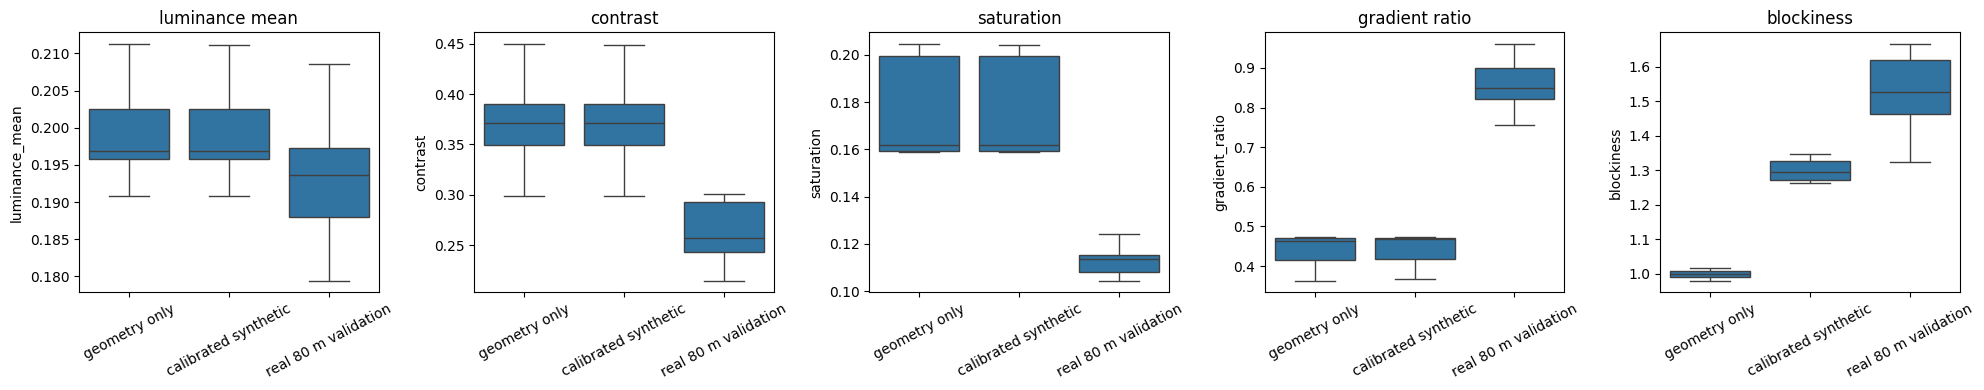

Saved calibration: C:\Users\ADMIN\Desktop\fastr\uav-altitude-feature-alignment\results\seadronessee_30m_to_80m_pilot\calibrated_effects.json
Saved metric figure: C:\Users\ADMIN\Desktop\fastr\uav-altitude-feature-alignment\results\seadronessee_30m_to_80m_pilot\calibration_validation_metrics.png


In [11]:
best = calibration_search.iloc[0]


def optional_number(value, integer=False):
    if pd.isna(value):
        return None
    return int(value) if integer else float(value)


CALIBRATED_EFFECTS_CANDIDATE = {
    "extra_psf_sigma_output_px": float(best["blur_sigma_output_px"]),
    "visibility_m": optional_number(best["visibility_m"]),
    "airlight_srgb": list(AIRLIGHT_SRGB),
    "peak_electrons": optional_number(best["peak_electrons"]),
    "read_noise_electrons": READ_NOISE_ELECTRONS,
    "jpeg_quality": optional_number(best["jpeg_quality"], integer=True),
}

geometry_validation_images = [
    {"image": render_prepared_source(item, effects=None, seed=RANDOM_SEED + index)}
    for index, item in enumerate(validation_sources)
]
calibrated_validation_images = [
    {"image": render_prepared_source(item, effects=CALIBRATED_EFFECTS_CANDIDATE, seed=RANDOM_SEED + index)}
    for index, item in enumerate(validation_sources)
]
geometry_validation_stats = statistics_frame(geometry_validation_images, "geometry only")
calibrated_validation_stats = statistics_frame(calibrated_validation_images, "calibrated synthetic")

geometry_validation_score, _ = distribution_score(geometry_validation_stats, real80_validation_stats)
calibrated_validation_score, _ = distribution_score(calibrated_validation_stats, real80_validation_stats)
CALIBRATION_ACCEPTED = calibrated_validation_score < geometry_validation_score
EFFECTS_FOR_DATASET = CALIBRATED_EFFECTS_CANDIDATE if CALIBRATION_ACCEPTED else {}

print("Candidate effects:")
print(json.dumps(CALIBRATED_EFFECTS_CANDIDATE, indent=2))
print(f"Geometry-only validation score: {geometry_validation_score:.4f}")
print(f"Calibrated validation score:    {calibrated_validation_score:.4f}")
print("Calibration accepted:", CALIBRATION_ACCEPTED)

comparison_stats = pd.concat(
    [geometry_validation_stats, calibrated_validation_stats, real80_validation_stats],
    ignore_index=True,
)
fig, axes = plt.subplots(1, len(CALIBRATION_METRICS), figsize=(20, 4))
for axis, metric in zip(axes, CALIBRATION_METRICS):
    sns.boxplot(data=comparison_stats, x="group", y=metric, ax=axis, showfliers=False)
    axis.set_title(metric.replace("_", " "))
    axis.tick_params(axis="x", rotation=28)
    axis.set_xlabel("")
plt.tight_layout()
metric_figure_path = RESULT_DIR / "calibration_validation_metrics.png"
fig.savefig(metric_figure_path, dpi=180, bbox_inches="tight")
plt.show()

calibration_record = {
    "method": "unlabelled low-level statistic matching",
    "real80_altitude_range_m": [REAL80_MIN_M, REAL80_MAX_M],
    "calibration_videos": CALIBRATION_VIDEOS,
    "validation_videos": VALIDATION_VIDEOS,
    "heldout_test_videos_not_opened": HELDOUT_TEST_VIDEOS,
    "metrics": CALIBRATION_METRICS,
    "metric_weights": METRIC_WEIGHTS,
    "candidate_effects": CALIBRATED_EFFECTS_CANDIDATE,
    "calibration_score": float(best["calibration_score"]),
    "geometry_validation_score": float(geometry_validation_score),
    "calibrated_validation_score": float(calibrated_validation_score),
    "accepted": bool(CALIBRATION_ACCEPTED),
    "effects_for_dataset": EFFECTS_FOR_DATASET,
}
calibration_path = RESULT_DIR / "calibrated_effects.json"
with calibration_path.open("w", encoding="utf-8") as handle:
    json.dump(calibration_record, handle, indent=2)
comparison_stats.to_csv(RESULT_DIR / "calibration_validation_statistics.csv", index=False)
print("Saved calibration:", calibration_path)
print("Saved metric figure:", metric_figure_path)

## 11. Apply the locked candidate to the two object examples

This figure is qualitative. Acceptance is determined by the separate validation-video statistic score above, not by choosing whichever example looks best.

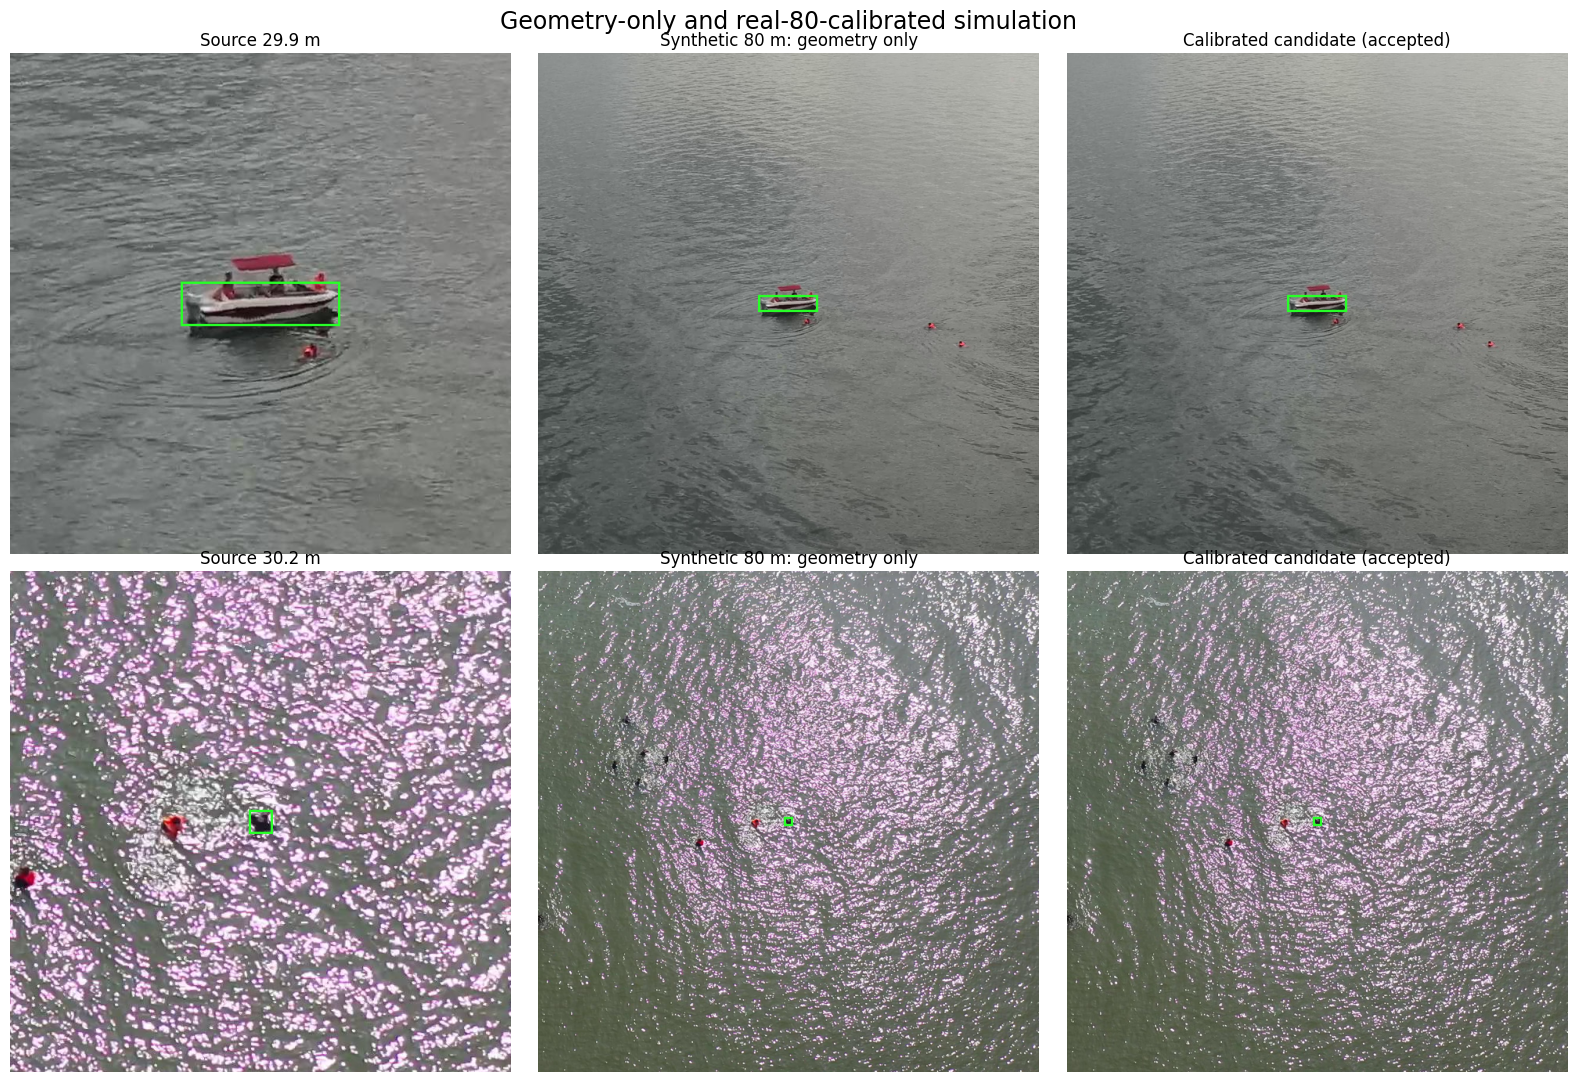

Saved calibrated comparison: C:\Users\ADMIN\Desktop\fastr\uav-altitude-feature-alignment\results\seadronessee_30m_to_80m_pilot\calibrated_pilot_comparison.png


In [12]:
fig, axes = plt.subplots(len(samples), 3, figsize=(16, 5.5 * len(samples)))
axes = np.atleast_2d(axes)
status = "accepted" if CALIBRATION_ACCEPTED else "rejected on validation"

for sample_index, row in samples.iterrows():
    with Image.open(row["image_path"]) as source_file:
        source = source_file.convert("RGB")
    input_30m, bbox_30m = centred_crop_with_bbox(source, row, OUTPUT_SIDE_PX)
    geometry_image, geometry_meta = simulate_30m_to_80m(source, row, effects=None, seed=RANDOM_SEED + sample_index)
    calibrated_image, calibrated_meta = simulate_30m_to_80m(
        source,
        row,
        effects=CALIBRATED_EFFECTS_CANDIDATE,
        seed=RANDOM_SEED + sample_index,
    )
    bbox_80m = geometry_meta["output_bbox"]
    rendered = [
        draw_bbox(input_30m, bbox_30m),
        draw_bbox(geometry_image, bbox_80m),
        draw_bbox(calibrated_image, bbox_80m),
    ]
    titles = [
        f"Source {row['altitude_m']:.1f} m",
        "Synthetic 80 m: geometry only",
        f"Calibrated candidate ({status})",
    ]
    for axis, image, title in zip(axes[sample_index], rendered, titles):
        axis.imshow(image)
        axis.set_title(title)
        axis.axis("off")
    stem = f"{sample_index + 1}_{row['category_name']}_{Path(row['file_name']).stem}"
    calibrated_image.save(RESULT_DIR / f"{stem}_synthetic80_calibrated.png")

fig.suptitle("Geometry-only and real-80-calibrated simulation", fontsize=17)
plt.tight_layout()
calibrated_figure_path = RESULT_DIR / "calibrated_pilot_comparison.png"
fig.savefig(calibrated_figure_path, dpi=180, bbox_inches="tight")
plt.show()
print("Saved calibrated comparison:", calibrated_figure_path)

## 12. Interpretation limits

This procedure calibrates a simulator to SeaDronesSee using a small amount of real target-domain imagery. It does **not** establish a camera-independent 80 m transformation.

A lower validation score means the candidate more closely matches the selected low-level statistic distributions on a different SeaDronesSee video. It does not prove that every component has been physically identified: water texture can resemble sensor noise, weather can resemble haze, and unpaired scenes can differ in illumination.

The next dataset-scale experiment should retain both variants:

```text
zero-shot arm: geometry-only synthetic 80 m
calibration-assisted arm: accepted calibrated effects with parameter randomisation
```

Both must be evaluated on the reserved `DJI_0064.MP4` and `DJI_0065.MP4` videos without adjusting the parameters after seeing their results. Recognition metrics on those videos remain separate from this low-level image-statistic calibration.